## Preprocessing

In [1]:
import pandas as pd
import numpy as np

In [2]:
cols = ['Unnamed: 0',
 'Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd Byts/b Avg',
 'Fwd Pkts/b Avg',
 'Fwd Blk Rate Avg',
 'Bwd Byts/b Avg',
 'Bwd Pkts/b Avg',
 'Bwd Blk Rate Avg',
 'Subflow Fwd Pkts',
 'Subflow Fwd Byts',
 'Subflow Bwd Pkts',
 'Subflow Bwd Byts',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Active Max',
 'Active Min',
 'Idle Mean',
 'Idle Std',
 'Idle Max',
 'Idle Min',
 'Label']

In [2]:
chunks = []
random_data_for_demo = []
chunk_size = 100000

for chunk_idx, chunk in enumerate(pd.read_csv("/kaggle/input/ddos-datasets/ddos_balanced/final_dataset.csv", chunksize=chunk_size)):
    chunk_ = chunk.sample(frac=0.25, random_state=42)
    random_ = chunk.sample(frac=0.01, random_state=42)
    
    chunks.append(chunk_)
    random_data_for_demo.append(random_)
    
    if chunk_idx%10 == 0:
        print(f"Chunk {chunk_idx} done")
print("Complete")

Chunk 0 done
Chunk 10 done
Chunk 20 done
Chunk 30 done
Chunk 40 done
Chunk 50 done
Chunk 60 done
Chunk 70 done
Chunk 80 done
Chunk 90 done
Chunk 100 done
Chunk 110 done
Chunk 120 done
Complete


In [3]:
df = pd.concat(chunks, ignore_index=True)
del chunks

df.to_parquet('/kaggle/working/sample_data.parquet', index=False)
print("Wrote file")

Wrote file


In [4]:
df_for_demo = pd.concat(random_data_for_demo, ignore_index=True)
del random_data_for_demo

df_for_demo.to_csv("/kaggle/working/data_for_demo.csv")
print("Wrote file")

Wrote file


In [5]:
df["Label"].value_counts()

Label
ddos      1618198
Benign    1580459
Name: count, dtype: int64

Wrote file


Uncomment to load the file

In [56]:
# df = pd.read_parquet("/kaggle/working/sample_data.parquet")

In [6]:
df.head()

,Unnamed: 0,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22165,172.31.69.25-18.219.211.138-80-34408-6,18.219.211.138,34408,172.31.69.25,80,6,15/02/2018 07:24:59 PM,5032233,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
1,26628,172.31.69.25-18.219.211.138-80-40676-6,18.219.211.138,40676,172.31.69.25,80,6,15/02/2018 07:26:24 PM,10993127,3,...,0,783.0,0.0,783.0,783.0,5990709.0,0.0,5990709.0,5990709.0,ddos
2,76682,192.168.2.109-203.73.24.75-4020-80-6,192.168.2.109,4020,203.73.24.75,80,6,12/06/2010 03:12:15 PM,479425,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
3,23143,172.31.69.25-18.219.211.138-80-36102-6,18.219.211.138,36102,172.31.69.25,80,6,15/02/2018 07:08:53 PM,9042123,1,...,0,0.0,0.0,0.0,0.0,9042123.0,0.0,9042123.0,9042123.0,ddos
4,39435,172.31.69.25-18.219.211.138-80-44284-6,18.219.211.138,44284,172.31.69.25,80,6,15/02/2018 07:19:56 PM,1907579,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos


In [ ]:
df.columns.tolist()

In [7]:
df.drop(columns=["Unnamed: 0", "Flow ID"], inplace=True)

In [8]:
df.head()

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,18.219.211.138,34408,172.31.69.25,80,6,15/02/2018 07:24:59 PM,5032233,3,5,603.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
1,18.219.211.138,40676,172.31.69.25,80,6,15/02/2018 07:26:24 PM,10993127,3,5,408.0,...,0,783.0,0.0,783.0,783.0,5990709.0,0.0,5990709.0,5990709.0,ddos
2,192.168.2.109,4020,203.73.24.75,80,6,12/06/2010 03:12:15 PM,479425,3,7,142.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
3,18.219.211.138,36102,172.31.69.25,80,6,15/02/2018 07:08:53 PM,9042123,1,1,0.0,...,0,0.0,0.0,0.0,0.0,9042123.0,0.0,9042123.0,9042123.0,ddos
4,18.219.211.138,44284,172.31.69.25,80,6,15/02/2018 07:19:56 PM,1907579,1,1,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos


In [9]:
# Convert IP strings into octets efficiently using NumPy
def ip_to_octets(ip_series, prefix):
    octets = np.stack(ip_series.str.split('.').apply(lambda x: list(map(int, x))))
    return pd.DataFrame(octets, columns=[f"{prefix} Octet{i+1}" for i in range(4)])

In [10]:
# Apply the optimized function
src_octets = ip_to_octets(df["Src IP"], "Src IP")
dst_octets = ip_to_octets(df["Dst IP"], "Dst IP")

# Concatenate with original DataFrame
df = pd.concat([df, src_octets, dst_octets], axis=1).drop(columns=["Src IP", "Dst IP"])

# Done
print("IP segmentation Done")

# Delete unused vars
del src_octets
del dst_octets

IP segmentation Done


In [11]:
columns_with_nan = df.columns[df.isnull().any()]

for col in columns_with_nan:
    print(f"Column '{col}' has {df[col].isnull().sum()} NaN values")

Column 'Flow Byts/s' has 7421 NaN values


In [12]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [13]:
df = pd.DataFrame(df.dropna(), columns=df.columns)

In [14]:
y = df["Label"]
X = df.drop(columns=["Label"])

In [15]:
print(y.isnull().any().sum())
print(X.isnull().any().sum())

0
0


In [16]:
y.nunique()

2

In [17]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

In [18]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
non_numerical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())
print(train_y.isnull().sum())
print(test_y.isnull().sum())

0
0
0
0


In [19]:
non_numerical_cols

['Timestamp']

In [20]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")

train_X[numerical_cols] = pd.DataFrame(imputer.fit_transform(train_X[numerical_cols]), columns=numerical_cols, index=train_X.index)  # DO NOT remove the index=xxx attribute, else NaN happens
test_X[numerical_cols] = pd.DataFrame(imputer.transform(test_X[numerical_cols]), columns=numerical_cols, index=test_X.index)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())

print("Imputing complete")

0
0
Imputing complete


In [21]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_X[numerical_cols])
train_X[numerical_cols] = pd.DataFrame(train_scaled, columns=numerical_cols, index=train_X.index)
test_X[numerical_cols] = pd.DataFrame(scaler.transform(test_X[numerical_cols]), columns=numerical_cols, index=test_X.index)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())

print("Scaling complete")

0
0
Scaling complete


In [24]:
import joblib
# Store imputer & scaler
joblib.dump(imputer, 'imputer.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("Saved prep models")

Saved prep models


In [25]:
train_X.head()
train_X.shape

(2549400, 88)

In [26]:
train_X.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
2969617,0.775326,0.000809,1.000000,20/02/2018 04:32:19,1.703750e-04,0.000003,0.000003,0.000003,9.306545e-08,0.001413,...,0.0,0.0,0.770270,0.121569,0.258824,0.086275,0.673228,0.121569,0.000000,0.007843
2784284,0.848142,0.006790,0.352941,20/02/2018 05:14:58,8.527592e-03,0.000019,0.000017,0.000046,5.156741e-07,0.005993,...,0.0,0.0,0.851351,0.796078,0.341176,0.576471,0.673228,0.121569,0.258824,0.298039
1218414,0.001221,0.895901,0.352941,16/02/2018 11:16:11 PM,3.719294e-02,0.000013,0.000017,0.000094,1.037451e-06,0.040026,...,0.0,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431
2979190,0.771130,0.001221,0.352941,20/02/2018 10:48:39,7.083334e-07,0.000006,0.000000,0.000000,0.000000e+00,0.000000,...,0.0,0.0,0.770270,0.121569,0.262745,0.196078,0.661417,0.996078,0.662745,0.996078
1890273,0.001221,0.755150,0.352941,03/07/2017 05:28:38 PM,1.666667e-08,0.000003,0.000003,0.000000,0.000000e+00,0.000000,...,0.0,0.0,0.099099,0.196078,0.270588,0.639216,0.751969,0.658824,0.039216,0.054902


In [27]:
train_X.isnull().any(axis=1).sum()

0

In [28]:
train_y = train_y.map({"Benign": 0, "ddos": 1})

In [29]:
test_y = test_y.map({"Benign": 0, "ddos": 1})

In [31]:
print(train_y.isnull().sum())
print(test_y.isnull().sum())

0
0


In [32]:
# to_parquet is only in a DF, so make DFs for Series objects
train_y_df = pd.DataFrame(train_y)
test_y_df = pd.DataFrame(test_y)

train_X.to_parquet("train_prepped_X.parquet")
test_X.to_parquet("test_prepped_X.parquet")
train_y_df.to_parquet("train_prepped_y.parquet")
test_y_df.to_parquet("test_prepped_y.parquet")

print("Files were written")

Files were written


In [33]:
# Load files
train_X = pd.read_parquet("/kaggle/input/sliit-final/data/train_prepped_X.parquet")
test_X = pd.read_parquet("/kaggle/input/sliit-final/data/test_prepped_X.parquet")
train_y_df = pd.read_parquet("/kaggle/input/sliit-final/data/train_prepped_y.parquet")
test_y_df = pd.read_parquet("/kaggle/input/sliit-final/data/test_prepped_y.parquet")

train_y = train_y_df['Label']
test_y = test_y_df['Label']

print("Loading complete")

Loading complete


## Logistic Regression

In [35]:
numerical_cols = train_X.select_dtypes(include=np.number).columns.tolist()
train_X[numerical_cols].shape

(2549400, 87)

In [36]:
from sklearn.linear_model import LogisticRegression

# Train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(train_X[numerical_cols], train_y.reset_index(drop=True))

# Print
print("Model trained successfully")

Model trained successfully


In [37]:
# Get default predictions (threshold at 0.5)
# y_pred = model.predict(test_X[numerical_cols])

# Get predicted probabilities
y_probs = model.predict_proba(test_X[numerical_cols])[:, 1]  # Probabilities for class 1

# Set custom threshold
threshold = 0.075  # Lower threshold to reduce false negatives
y_pred = (y_probs >= threshold).astype(int)

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [39]:
train_X[numerical_cols].shape, test_X[numerical_cols].shape

((2549400, 87), (637351, 87))

In [40]:
print("Accuracy:", accuracy_score(test_y.reset_index(drop=True), y_pred))
print("\nClassification Report:\n", classification_report(test_y, y_pred))

Accuracy: 0.9848686202736012

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98    314001
           1       0.97      1.00      0.99    323350

    accuracy                           0.98    637351
   macro avg       0.99      0.98      0.98    637351
weighted avg       0.99      0.98      0.98    637351



In [45]:
accuracy = accuracy_score(test_y.reset_index(drop=True), y_pred)
precision = precision_score(test_y, y_pred)
recall = recall_score(test_y, y_pred)
f1 = f1_score(test_y, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9849
Precision: 0.9719
Recall: 0.9991
F1 Score: 0.9853


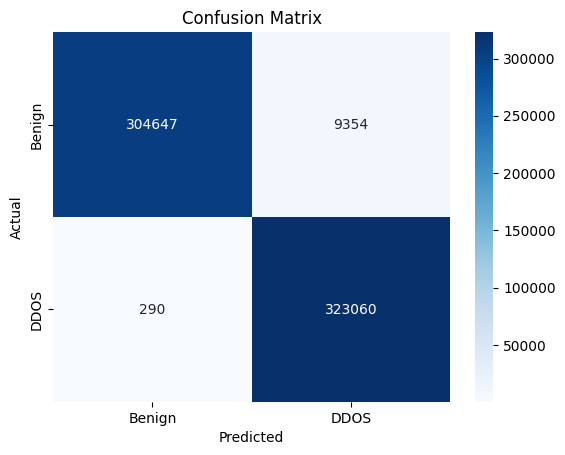

In [42]:
conf_matrix = confusion_matrix(test_y.reset_index(drop=True), y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign', 'DDOS'], yticklabels=['Benign', 'DDOS'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("log_reg.png")
plt.show()

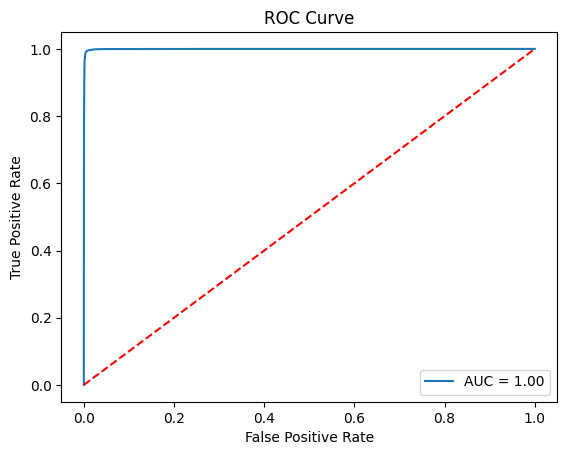

In [43]:
y_pred_proba = model.predict_proba(test_X[numerical_cols])[:,1]
fpr, tpr, _ = roc_curve(test_y.reset_index(drop=True), y_pred_proba)
auc = roc_auc_score(test_y.reset_index(drop=True), y_pred_proba)
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [44]:
import joblib
joblib.dump(model, '/kaggle/working/log_reg_model.pkl')

['/kaggle/working/log_reg_model.pkl']

## Autoencoder

In [6]:
train_X.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
2969617,0.775326,0.000809,1.000000,20/02/2018 04:32:19,1.703750e-04,0.000003,0.000003,0.000003,9.306545e-08,0.001413,...,0.0,0.0,0.770270,0.121569,0.258824,0.086275,0.673228,0.121569,0.000000,0.007843
2784284,0.848142,0.006790,0.352941,20/02/2018 05:14:58,8.527592e-03,0.000019,0.000017,0.000046,5.156741e-07,0.005993,...,0.0,0.0,0.851351,0.796078,0.341176,0.576471,0.673228,0.121569,0.258824,0.298039
1218414,0.001221,0.895901,0.352941,16/02/2018 11:16:11 PM,3.719294e-02,0.000013,0.000017,0.000094,1.037451e-06,0.040026,...,0.0,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431
2979190,0.771130,0.001221,0.352941,20/02/2018 10:48:39,7.083334e-07,0.000006,0.000000,0.000000,0.000000e+00,0.000000,...,0.0,0.0,0.770270,0.121569,0.262745,0.196078,0.661417,0.996078,0.662745,0.996078
1890273,0.001221,0.755150,0.352941,03/07/2017 05:28:38 PM,1.666667e-08,0.000003,0.000003,0.000000,0.000000e+00,0.000000,...,0.0,0.0,0.099099,0.196078,0.270588,0.639216,0.751969,0.658824,0.039216,0.054902


In [7]:
train_y.reset_index(drop=True).head()
pd.DataFrame(train_y).head()

,Label
2969617,0
2784284,0
1218414,1
2979190,0
1890273,0


In [9]:
# train_X_benign = train_X[pd.DataFrame(train_y).reset_index(drop=True)["Label"]==0].reset_index(drop=True)  # TODO: Why this doesn't work??
numerical_cols = train_X.select_dtypes(include=np.number).columns.tolist()
non_numerical_cols = train_X.select_dtypes(exclude=np.number).columns.tolist()
train_X_benign = train_X[pd.DataFrame(train_y)["Label"]==0].reset_index(drop=True)[numerical_cols]
train_X_benign.isna().any(axis=1).sum()

0

In [10]:
train_X_benign.head()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
0,0.775326,0.000809,1.000000,1.703750e-04,0.000003,0.000003,0.000003,9.306545e-08,0.001413,0.022418,...,0.0,0.0,0.770270,0.121569,0.258824,0.086275,0.673228,0.121569,0.000000,0.007843
1,0.848142,0.006790,0.352941,8.527592e-03,0.000019,0.000017,0.000046,5.156741e-07,0.005993,0.000000,...,0.0,0.0,0.851351,0.796078,0.341176,0.576471,0.673228,0.121569,0.258824,0.298039
2,0.771130,0.001221,0.352941,7.083334e-07,0.000006,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.0,0.0,0.770270,0.121569,0.262745,0.196078,0.661417,0.996078,0.662745,0.996078
3,0.001221,0.755150,0.352941,1.666667e-08,0.000003,0.000003,0.000000,0.000000e+00,0.000000,0.000000,...,0.0,0.0,0.099099,0.196078,0.270588,0.639216,0.751969,0.658824,0.039216,0.054902
4,0.006760,0.536973,0.352941,9.166667e-08,0.000000,0.000007,0.000000,0.000000e+00,0.000000,0.000000,...,0.0,0.0,0.148649,0.784314,0.752941,0.180392,0.751969,0.658824,0.039216,0.200000


In [11]:
train_X_benign.shape

(1254561, 87)

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

In [13]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim): # x -> x' -> x'' 
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.SELU(),
            nn.Linear(64, 32),
            nn.SELU(),
            nn.Linear(32, 8),
            nn.SELU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),
            nn.SELU(),
            nn.Linear(32, 64),
            nn.SELU(),
            nn.Linear(64, input_dim),
            nn.SELU()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [14]:
input_dim = train_X_benign.shape[1]
model = Autoencoder(input_dim)
criterion = nn.L1Loss()
optimizer = optim.RMSprop(model.parameters(), lr=0.0001)

In [ ]:
# train_X_backup = train_X.copy()
# test_X_backup = test_X.copy()
# train_y_backup = train_y.copy()
# test_y_backup = test_y.copy()
# train_X_benign_backup = train_X_benign.copy()

# train_X = train_X_backup.copy()
# test_X = test_X_backup.copy()
# train_y = train_y_backup.copy()
# test_y = test_y_backup.copy()
# train_X_benign = train_X_benign_backup.copy()

In [15]:
if not isinstance(train_X, torch.Tensor):
    train_X = torch.FloatTensor(train_X[numerical_cols].values)
if not isinstance(train_y, torch.Tensor):
    train_y = torch.LongTensor(train_y.values)
if not isinstance(test_X, torch.Tensor):
    test_X = torch.FloatTensor(test_X[numerical_cols].values)
if not isinstance(test_y, torch.Tensor):
    test_y = torch.LongTensor(test_y.values)
if not isinstance(train_X_benign, torch.Tensor):
    train_X_benign = torch.FloatTensor(train_X_benign.values)

In [16]:
print(type(train_X))
print(type(train_y))
print(type(test_X))
print(type(test_y))
print(type(train_X_benign))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [17]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(train_X_benign), batch_size=32, shuffle=True)
epochs = 20

In [18]:
epoch_losses = []
reconstruction_losses_last_epoch = [] 
for epoch in range(epochs):
    model.train()   # set the model to training mode 
    total_loss = 0
    # using mini batch gradient descent
    for batch in train_loader:
        inputs = batch[0]
        optimizer.zero_grad()    # reset the gradients for each batch
        outputs = model(inputs)  # forward pass
        loss = criterion(outputs, inputs)    
        loss.backward()     # backward pass
        optimizer.step()    # update the weights
        total_loss += loss.item()

        # Track individual sample reconstruction losses only in the last epoch
        if epoch == epochs - 1:  # Collect only for the last epoch
            reconstruction_losses_last_epoch.extend(loss.item() for _ in range(len(inputs)))
            
    epoch_loss = total_loss/len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}') 
print("Autoencoder training complete")

Epoch 1/20, Loss: 0.0333
Epoch 2/20, Loss: 0.0229
Epoch 3/20, Loss: 0.0212
Epoch 4/20, Loss: 0.0175
Epoch 5/20, Loss: 0.0163
Epoch 6/20, Loss: 0.0157
Epoch 7/20, Loss: 0.0152
Epoch 8/20, Loss: 0.0149
Epoch 9/20, Loss: 0.0147
Epoch 10/20, Loss: 0.0145
Epoch 11/20, Loss: 0.0143
Epoch 12/20, Loss: 0.0142
Epoch 13/20, Loss: 0.0141
Epoch 14/20, Loss: 0.0140
Epoch 15/20, Loss: 0.0138
Epoch 16/20, Loss: 0.0137
Epoch 17/20, Loss: 0.0134
Epoch 18/20, Loss: 0.0130
Epoch 19/20, Loss: 0.0127
Epoch 20/20, Loss: 0.0124
Autoencoder training complete


In [19]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

reconstruction_losses_last_epoch = np.array(reconstruction_losses_last_epoch)

mean_loss = np.mean(reconstruction_losses_last_epoch)
std_loss = np.std(reconstruction_losses_last_epoch)

threshold = 1 * mean_loss + 2.5 * std_loss # Define threshold to have the highest recall possible. 

print(f"Anomaly Detection Threshold: {threshold}")

Anomaly Detection Threshold: 0.017251603054865443


In [20]:
model.eval()
reconstruction_errors = []
test_labels = test_y.numpy()

with torch.no_grad():
    outputs = model(test_X)
    reconstruction_errors = torch.mean(torch.abs(outputs - test_X), dim=1).numpy()

predicted_labels = (reconstruction_errors > threshold).astype(int)

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
accuracy = accuracy_score(test_labels, predicted_labels)
precision = precision_score(test_labels, predicted_labels)
recall = recall_score(test_labels, predicted_labels)
f1 = f1_score(test_labels, predicted_labels)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8024
Precision: 0.7201
Recall: 0.9987
F1 Score: 0.8368


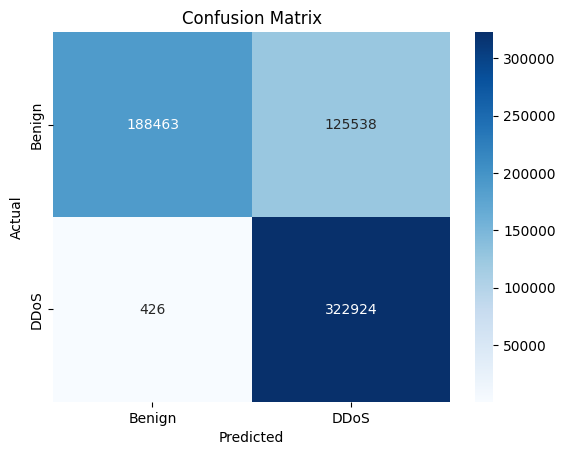

In [32]:
cm = confusion_matrix(test_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("autoencoder_conf.png")
plt.show()

In [30]:
torch.save(model, "/kaggle/working/autoencoder.pt")

## LSTM

In [2]:
# Load files
train_X = pd.read_parquet("/kaggle/input/sliit-final/data/train_prepped_X.parquet")
test_X = pd.read_parquet("/kaggle/input/sliit-final/data/test_prepped_X.parquet")
train_y_df = pd.read_parquet("/kaggle/input/sliit-final/data/train_prepped_y.parquet")
test_y_df = pd.read_parquet("/kaggle/input/sliit-final/data/test_prepped_y.parquet")

train_y = train_y_df['Label']
test_y = test_y_df['Label']

print("Loading complete")

Loading complete


In [7]:
train_X.head()
# test_X.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
829470,0.645029,0.001221,0.352941,16/02/2018 11:18:18 PM,1.086667e-05,0.000003,0.000003,0.000000,0.0,0.000000,...,0.0,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
1014573,0.809827,0.001221,0.352941,16/02/2018 11:23:30 PM,3.900000e-04,0.000006,0.000003,0.000000,0.0,0.000000,...,0.0,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
985099,0.821790,0.001221,0.352941,16/02/2018 11:22:24 PM,2.001667e-05,0.000003,0.000003,0.000000,0.0,0.000000,...,0.0,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
1704264,0.006760,0.804849,0.352941,20/02/2018 01:09:42,2.583333e-07,0.000010,0.000003,0.000008,0.0,0.001969,...,0.0,0.0,0.135135,0.050980,0.254902,0.141176,0.673228,0.121569,0.258824,0.286275
71153,0.937453,0.001221,0.352941,21/02/2018 11:44:06 PM,8.735000e-05,0.000003,0.000003,0.000000,0.0,0.000000,...,0.0,0.0,0.076577,0.854902,0.215686,0.494118,0.673228,0.121569,0.270588,0.109804


For now let's consider the training set as our only data source and train the LSTM on it

In [3]:
train_y.head()
# test_y.head()

2969617    0
2784284    0
1218414    1
2979190    0
1890273    0
Name: Label, dtype: int64

### merge y to X

In [4]:
data_train = train_X  # pandas use copy-on-write. So once data is been modified, data and train_X will be different and WONT share the same object.
data_test = test_X
# print(data is train_X)
data_train['Label'] = train_y
data_test['Label'] = test_y
# print(data['Label'] is train_y)
data_train.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4,Label
2969617,0.775326,0.000809,1.000000,20/02/2018 04:32:19,1.703750e-04,0.000003,0.000003,0.000003,9.306545e-08,0.001413,...,0.0,0.770270,0.121569,0.258824,0.086275,0.673228,0.121569,0.000000,0.007843,0
2784284,0.848142,0.006790,0.352941,20/02/2018 05:14:58,8.527592e-03,0.000019,0.000017,0.000046,5.156741e-07,0.005993,...,0.0,0.851351,0.796078,0.341176,0.576471,0.673228,0.121569,0.258824,0.298039,0
1218414,0.001221,0.895901,0.352941,16/02/2018 11:16:11 PM,3.719294e-02,0.000013,0.000017,0.000094,1.037451e-06,0.040026,...,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431,1
2979190,0.771130,0.001221,0.352941,20/02/2018 10:48:39,7.083334e-07,0.000006,0.000000,0.000000,0.000000e+00,0.000000,...,0.0,0.770270,0.121569,0.262745,0.196078,0.661417,0.996078,0.662745,0.996078,0
1890273,0.001221,0.755150,0.352941,03/07/2017 05:28:38 PM,1.666667e-08,0.000003,0.000003,0.000000,0.000000e+00,0.000000,...,0.0,0.099099,0.196078,0.270588,0.639216,0.751969,0.658824,0.039216,0.054902,0


In [5]:
from sklearn.model_selection import train_test_split

# Reason for not taking the test part from data_train => data_train are scaled and imputed using fit_transform, so they can't be used for test data. Else data leakage happens

data_train_sample, _ = train_test_split(data_train, train_size=0.05, stratify=data_train["Label"], random_state=42)
data_test_sample, _ = train_test_split(data_test, train_size=0.05, stratify=data_test["Label"], random_state=42)

data_train_sample.shape, data_test_sample.shape

((127470, 89), (31867, 89))

In [6]:
def parse_mixed_formats(timestamp):
    try:
        # Try parsing with AM/PM (12-hour format)
        return pd.to_datetime(timestamp, format="%d/%m/%Y %I:%M:%S %p", dayfirst=True)
    except ValueError:
        try:
            # Try parsing without AM/PM (24-hour format)
            return pd.to_datetime(timestamp, format="%d/%m/%Y %H:%M:%S", dayfirst=True)
        except ValueError:
            return pd.NaT  # Return NaT for invalid formats
            
data_train_sample['Timestamp'] = data_train_sample['Timestamp'].apply(parse_mixed_formats)
data_test_sample['Timestamp'] = data_test_sample['Timestamp'].apply(parse_mixed_formats)
print("Done TS parsing")

Done TS parsing


In [7]:
data_train_sample.head(10)

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4,Label
1412940,0.001221,0.568926,0.352941,2018-02-16 23:22:30,3.647725e-02,0.000013,0.000014,0.000094,5.278794e-07,0.040026,...,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431,1
2246113,0.006760,0.781976,0.352941,2018-02-20 11:27:55,4.583333e-07,0.000010,0.000003,0.000003,0.000000e+00,0.001327,...,0.0,0.099099,0.768627,0.443137,0.670588,0.673228,0.121569,0.250980,0.486275,0
2588510,0.931289,0.001221,0.352941,2017-07-03 20:03:12,1.499183e-03,0.000013,0.000014,0.000046,4.332883e-07,0.019649,...,0.0,0.860360,0.658824,0.039216,0.098039,0.192913,0.070588,0.196078,0.235294,0
3097000,0.804242,0.006760,0.352941,2018-02-20 12:43:46,2.308333e-06,0.000010,0.000000,0.000008,0.000000e+00,0.001969,...,0.0,0.770270,0.121569,0.262745,0.145098,0.287402,0.490196,0.109804,0.415686,0
1304187,0.001221,0.649678,0.352941,2018-02-16 23:19:36,3.556813e-02,0.000013,0.000014,0.000094,5.324564e-07,0.040026,...,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431,1
2456944,0.886564,0.000809,1.000000,2018-02-20 02:41:02,2.583333e-06,0.000003,0.000003,0.000004,8.696280e-08,0.001755,...,0.0,0.770270,0.121569,0.250980,0.176471,0.673228,0.121569,0.000000,0.007843,0
95182,0.977356,0.001221,0.352941,2018-02-21 23:46:10,6.185833e-05,0.000006,0.000017,0.000034,1.426495e-06,0.014512,...,0.0,0.076577,0.854902,0.898039,0.921569,0.673228,0.121569,0.270588,0.109804,1
2210217,0.944106,0.051714,0.352941,2018-02-20 02:12:00,2.288422e-02,0.000026,0.000024,0.000116,2.412073e-06,0.028981,...,0.0,0.504505,0.635294,0.968627,0.709804,0.673228,0.121569,0.262745,0.066667,0
2580869,0.006760,0.808969,0.352941,2018-02-20 03:48:09,3.050000e-06,0.000010,0.000000,0.000003,0.000000e+00,0.001327,...,0.0,0.229730,0.282353,0.521569,0.560784,0.673228,0.121569,0.258824,0.427451,0
1430485,0.001221,0.898618,0.352941,2018-02-16 23:22:34,9.648056e-02,0.000013,0.000031,0.000094,9.428598e-07,0.040026,...,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431,1


In [8]:
# Check for pd.NaT in Timestamp column
print(data_train_sample['Timestamp'].isnull().sum())
print(data_test_sample['Timestamp'].isnull().sum())

0
0


In [9]:
# save 
data_train_sample.to_parquet("lstm_data_train_sample.parquet")
data_test_sample.to_parquet("lstm_data_test_sample.parquet")
print("Saving complete")

Saving complete


In [11]:
# load
import pandas as pd
data_train_sample = pd.read_parquet("/kaggle/working/lstm_data_train_sample.parquet")
data_test_sample = pd.read_parquet("/kaggle/working/lstm_data_test_sample.parquet")
print("Loading complete")

Loading complete


In [12]:
data_train_sample = data_train_sample.sort_values(by='Timestamp')
data_test_sample = data_test_sample.sort_values(by='Timestamp')
data_train_sample.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4,Label
10424,0.069490,0.001221,0.352941,2010-06-12 08:37:22,4.166667e-06,0.000006,0.000003,0.000000,0.000000,0.000000,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
20161,0.069856,0.001221,0.352941,2010-06-12 08:37:48,5.525183e-03,0.000006,0.000021,0.000009,0.000003,0.003724,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
23896,0.062272,0.001221,0.352941,2010-06-12 09:12:08,1.358333e-06,0.000003,0.000003,0.000000,0.000000,0.000000,...,0.0,0.86036,0.658824,0.007843,0.431373,0.259843,0.862745,0.839216,0.196078,1
13355,0.062486,0.001221,0.352941,2010-06-12 09:12:13,5.416667e-07,0.000003,0.000003,0.000000,0.000000,0.000000,...,0.0,0.86036,0.658824,0.007843,0.431373,0.259843,0.862745,0.839216,0.196078,1
13520,0.062699,0.001221,0.352941,2010-06-12 09:12:17,1.761367e-03,0.000006,0.000017,0.000006,0.000001,0.002568,...,0.0,0.86036,0.658824,0.007843,0.431373,0.259843,0.862745,0.839216,0.196078,1


In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [14]:
class NetworkTrafficDataset(Dataset):
    def __init__(self, data, seq_length=50):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length  # Number of sequences

    def __getitem__(self, index):
        X = self.data.iloc[index:index + self.seq_length].drop(columns=['Label']).values
        y = self.data.iloc[index + self.seq_length]['Label']
        
        # Convert to tensors
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)  # Classification task
        
        return X_tensor, y_tensor


In [15]:
from sklearn.model_selection import train_test_split

train_data = data_train_sample.copy()
test_data = data_test_sample.copy()

# Load your dataset
# df = data.copy()

# get feature count
features = train_data.drop(columns=['Label', 'Timestamp'])

# # Split into train and test sets
# train_data, test_data = train_test_split(df, test_size=0.95, stratify=df['Label'], random_state=42)

# Ensure data is sorted by timestamp
train_data = train_data.sort_values(by="Timestamp")
train_data = train_data.drop(columns=["Timestamp"])
test_data = test_data.sort_values(by="Timestamp")
test_data = test_data.drop(columns=["Timestamp"])

# Sequence length
seq_length = 50
batch_size = 32

# Create Dataset and DataLoader
train_dataset = NetworkTrafficDataset(train_data, seq_length)
test_dataset = NetworkTrafficDataset(test_data, seq_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")

Training data size: 127470
Testing data size: 31867


In [19]:
features.shape

(127470, 87)

In [16]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))  # LSTM forward pass
        out = self.fc(out[:, -1, :])  # Take the output of the last time step
        return out


In [17]:
# Model parameters
input_size = len(features.columns)  # Number of features
hidden_size = 128
num_layers = 2
output_size = 2  # Binary classification (DDOS or not)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = LSTMModel(input_size, hidden_size, num_layers, output_size).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.0025)

# Training loop config
num_epochs = 10
total_items = 0

# time specific imports and config
import pytz
import datetime
my_timezone = pytz.timezone("Asia/Colombo")

start_time = datetime.datetime.utcnow()
start_local = start_time.astimezone(my_timezone)
utc_now = datetime.datetime.utcnow()
local_now = utc_now.astimezone(my_timezone)
print(f"Training started at: {local_now.strftime('%a, %b %d %Y %H:%M:%S %Z')}")

# Loop
for epoch in range(num_epochs):
    lstm_model.train()
    total_loss = 0
    # epoch_start = time.time()  # Start time of the epoch

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_items += X_batch.size(0) 
        
    # epoch_end = time.time()  # End time of the epoch
    # epoch_duration = (epoch_end - epoch_start) / 60
    utc_now = datetime.datetime.utcnow()
    local_now = utc_now.astimezone(my_timezone)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Time: {local_now.strftime('%a, %b %d %Y %H:%M:%S %Z')}")
    
# end_time = time.time()  # End time of the training
end_time = datetime.datetime.utcnow()
end_local = end_time.astimezone(my_timezone)
duration = end_time - start_time
total_seconds = duration.total_seconds()
minutes, seconds = divmod(int(total_seconds), 60)
# total_duration = (end_time - start_time) / 60  # Convert seconds to minutes
print("---")
print(f"\nTraining completed successfully")
print(f"Total training time: {minutes} mins, {seconds} seconds")
print(f"Training started at: {start_local.strftime('%a, %b %d %Y %H:%M:%S %Z')}")
print(f"Training ended at: {end_local.strftime('%a, %b %d %Y %H:%M:%S %Z')}")
print("---")
print(f"Total items processed: {total_items}")

Training started at: Mon, Mar 03 2025 20:46:40 +0530
Epoch 1/10, Loss: 0.1002, Time: Mon, Mar 03 2025 20:51:11 +0530
Epoch 2/10, Loss: 0.0741, Time: Mon, Mar 03 2025 20:55:46 +0530
Epoch 3/10, Loss: 0.0731, Time: Mon, Mar 03 2025 21:00:21 +0530
Epoch 4/10, Loss: 0.0731, Time: Mon, Mar 03 2025 21:04:56 +0530
Epoch 5/10, Loss: 0.0726, Time: Mon, Mar 03 2025 21:09:28 +0530
Epoch 6/10, Loss: 0.0725, Time: Mon, Mar 03 2025 21:14:01 +0530
Epoch 7/10, Loss: 0.0723, Time: Mon, Mar 03 2025 21:18:33 +0530
Epoch 8/10, Loss: 0.0722, Time: Mon, Mar 03 2025 21:23:05 +0530
Epoch 9/10, Loss: 0.0727, Time: Mon, Mar 03 2025 21:27:43 +0530
Epoch 10/10, Loss: 0.0722, Time: Mon, Mar 03 2025 21:32:15 +0530
---

Training completed successfully
Total training time: 45 mins, 35 seconds
Training started at: Mon, Mar 03 2025 20:46:40 +0530
Training ended at: Mon, Mar 03 2025 21:32:15 +0530
---
Total items processed: 1274200


In [18]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score, confusion_matrix, 
                             roc_curve, precision_recall_curve, classification_report, 
                             matthews_corrcoef)

lstm_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = lstm_model(X_batch)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# # Calculate accuracy
# accuracy = accuracy_score(all_labels, all_preds)
# print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Compute Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
# mcc = matthews_corrcoef(all_labels, all_preds)  # Balanced metric for imbalanced data
roc_auc = roc_auc_score(all_labels, all_preds)
# average_precision = average_precision_score(all_labels, all_preds)

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = conf_matrix.ravel()

# Additional Metrics
# specificity = tn / (tn + fp)  # True Negative Rate
# false_positive_rate = fp / (fp + tn)  # 1 - Specificity
# false_negative_rate = fn / (fn + tp)  # Miss Rate
# fpr, tpr, _ = roc_curve(all_labels, all_preds)
# precisions, recalls, _ = precision_recall_curve(all_labels, all_preds)

# Print Metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
# print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
# print(f"Average Precision Score: {average_precision:.4f}")
# print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
# print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")
# print(f"False Negative Rate (FNR): {false_negative_rate:.4f}")

print("\nClassification Report:\n", classification_report(all_labels, all_preds))
print("\nConfusion Matrix:\n", conf_matrix)

Accuracy: 95.34%
Precision: 0.9989
Recall (Sensitivity): 0.9089
F1-score: 0.9518
ROC-AUC Score: 0.9539

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95     15700
           1       1.00      0.91      0.95     16117

    accuracy                           0.95     31817
   macro avg       0.96      0.95      0.95     31817
weighted avg       0.96      0.95      0.95     31817


Confusion Matrix:
 [[15684    16]
 [ 1468 14649]]


In [21]:
torch.save(lstm_model, "/kaggle/working/lstm.pt")
torch.save(lstm_model.state_dict(), "lstm_state_dict.pth")

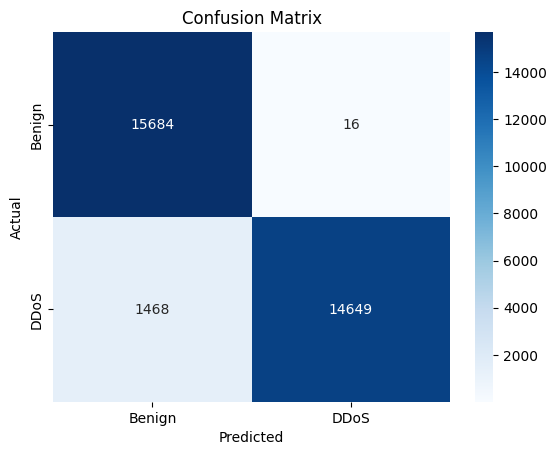

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("lstm_conf.png")
plt.show()